In [2]:
# Jaxlib
import jax
from jax import lax
from jax import random as jrnd
from jax import numpy as jnp
from jax import tree_util as jtu
jax.config.update('jax_enable_x64', True)

# Others
from matplotlib import pyplot as plt

# This
from numerics import *
from seismic import *

In [62]:
gmms = [gmm_ASK14, gmm_BSSA14, gmm_CB14, gmm_CY14, gmm_Idriss14]
gmms = gmms + [gmm_epi_AAY14(gmm, -1.645) for gmm in gmms] + [gmm_epi_AAY14(gmm, 1.645) for gmm in gmms]
gmmlt = GMMLT(gmms, .5, jnp.ones(len(gmms)) / len(gmms))
gmm_idcs = jnp.arange(len(gmms))

lnR = jnp.linspace(0.1, 4, 7)
M = jnp.linspace(4., 8, 7)
MlnR = jnp.stack(jnp.meshgrid(lnR, M), axis = -1).reshape(7**2, 2)
M, lnR = MlnR.T
x = jnp.exp(lnR)
y = 0

faults = jax.vmap(Fault, in_axes = (0, None, None, None, None, None, None, None, None, None))(x, y, 5.3, 0.1, 30, 45, 20, 1.2, 0., MFD(2, 1))

vmap_gmms = jax.vmap(gmmlt.calc_single, in_axes = (0, None, None, None, None))
vmap_MlnR = jax.vmap(vmap_gmms, in_axes = (None, 0, None, 0, 0))
site = Site(0, 0, 760, 1.2, 3.5, 0.)
gmm_out, _ = vmap_MlnR(gmm_idcs, M, site, faults, jax.vmap(calc_R, in_axes = (None, 0))(site, faults))

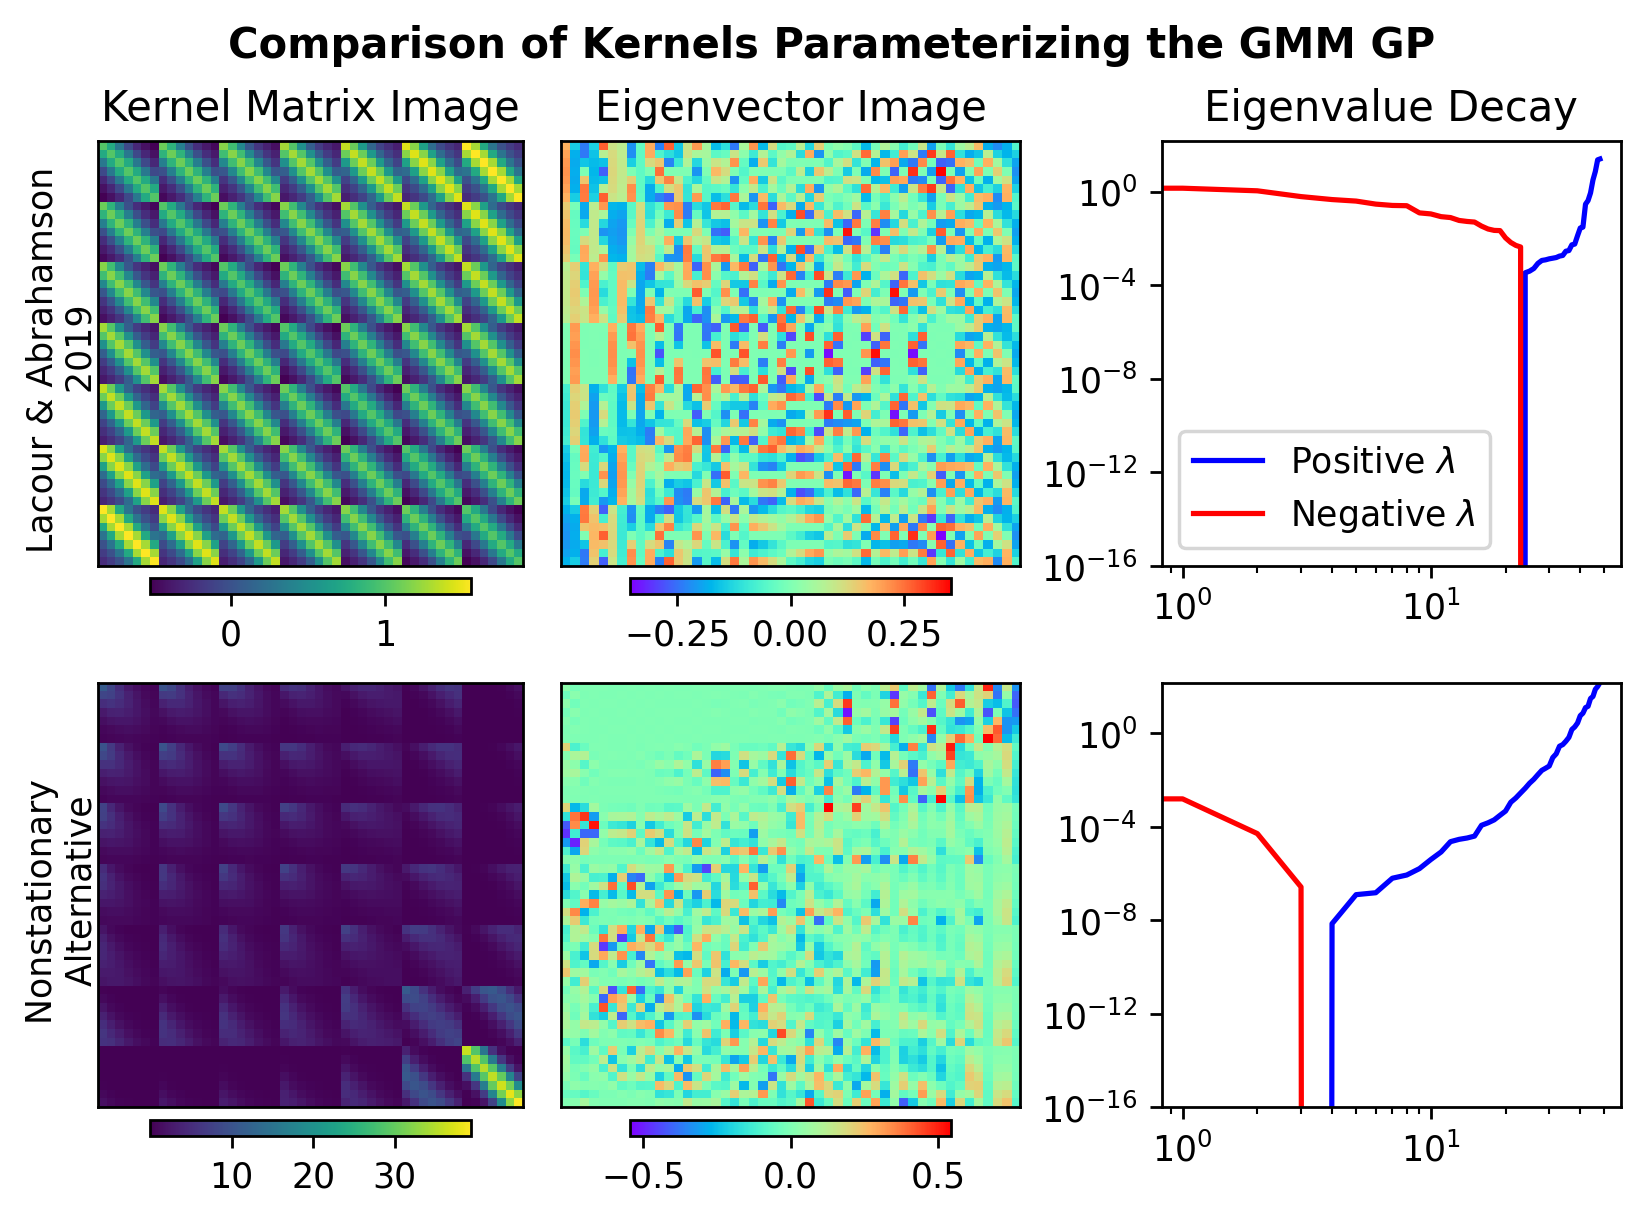

In [67]:
fig,ax = plt.subplots(2, 3, layout = 'constrained', dpi = 250)
eigmin = 0
eigmax = 0
K_imgs = []
for i,C in enumerate([C_Lacour, C_Paciorek]):
    K = C(MlnR, gmm_out)
    eigvals, eigvecs = jnpla.eigh(K)
    K_eigmin = eigvals.min()
    K_eigmax = eigvals.max()
    eigmin = min(eigmin, jnp.abs(K_eigmin))
    eigmax = max(eigmax, K_eigmax)
    vecabs = max(jnp.max(eigvecs), jnp.max(jnp.abs(eigvecs)))
    K_img = ax[i, 0].imshow(K)
    plt.colorbar(K_img, orientation = 'horizontal', shrink = 0.7, pad = -0.1)
    eig_img = ax[i, 1].imshow(eigvecs, cmap = 'rainbow', origin = 'lower', aspect = 'auto', vmin = -vecabs, vmax = vecabs)
    plt.colorbar(eig_img, orientation = 'horizontal', shrink = 0.7, pad = -0.1)
    ax[i, 2].plot(eigvals * (eigvals > 0), c = 'b', label = 'Positive '+r'$\lambda$')
    ax[i, 2].plot(jnp.abs(eigvals) * (eigvals < 0), c = 'r', label = 'Negative '+r'$\lambda$')
ax[0, 2].legend()

for i,name in enumerate(['Lacour & Abrahamson \n 2019', 'Nonstationary \n Alternative']):
    # Hide x, y labels on kernel viz
    ax[i, 0].set_xticks([])
    ax[i, 0].set_yticks([])
    # Hide x, y labels on eigenvector viz
    ax[i, 1].set_xticks([])
    ax[i, 1].set_yticks([])
    # Eigvals
    ax[i, 2].set_ylim(1e-16, eigmax)
    ax[i, 2].set_yscale('log')
    ax[i, 2].set_xscale('log')
    ax[i, 0].set_ylabel(name, rotation = 90, labelpad = 0)

for j,colname in enumerate(['Kernel Matrix Image', 'Eigenvector Image', 'Eigenvalue Decay']):
    ax[0,j].set_title(colname)
plt.suptitle('Comparison of Kernels Parameterizing the GMM GP', fontweight = 'semibold')
plt.savefig('figures/C_eig_properties.png', )